|<h2>Course:</h2>|<h1><a href="https://udemy.com/course/deeplearning_x/?couponCode=202508" target="_blank">A deep understanding of deep learning</a></h1>|
|-|:-:|
|<h2>Section:</h2>|<h1>Understand and design CNNs<h1>|
|<h2>Lecture:</h2>|<h1><b>Do autoencoders clean Gaussians?<b></h1>|

<br>

<h5><b>Teacher:</b> Mike X Cohen, <a href="https://sincxpress.com" target="_blank">sincxpress.com</a></h5>
<h5><b>Course URL:</b> <a href="https://udemy.com/course/deeplearning_x/?couponCode=202508" target="_blank">udemy.com/course/deeplearning_x/?couponCode=202508</a></h5>
<i>Using the code without the course may lead to confusion or errors.</i>

In [1]:
# import libraries
import numpy as np

import copy
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

# model summary info
from torchsummary import summary

import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

In [2]:
# Idenitfy device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


# Create Gaussian blurs with varying widths and occluding bars

In [3]:
def generate_gauss_data(imgSize:int, nGauss:int):
  x = np.linspace(-4,4,imgSize)
  X,Y = np.meshgrid(x,x)

  # vary the weights smoothly
  widths = np.linspace(2,20,nGauss)

  # initialize tensor containing images
  images = torch.zeros(nGauss,1,imgSize,imgSize)

  for i in range(nGauss):

    # create the gaussian with random centers
    ro = 1.5*np.random.randn(2) # ro = random offset
    G  = np.exp( -( (X-ro[0])**2 + (Y-ro[1])**2) / widths[i] )

    # and add noise
    G  = G + np.random.randn(imgSize,imgSize)/5

    # add a random bar randomly
    i1 = np.random.choice(np.arange(2,28))
    i2 = np.random.choice(np.arange(2,6))
    if np.random.randn()>0:
      G[i1:i1+i2,] = 1
    else:
      G[:,i1:i1+i2] = 1
      
    # Normalize the image to be between 0 and 1 (use min-max normalization)
    G = (G - np.min(G)) / (np.max(G) - np.min(G))

    # add to the tensor
    images[i,:,:,:] = torch.Tensor(G).view(1,imgSize,imgSize)
    
  return copy.deepcopy(images)

imgSize = 91  # image size
num_samples  = 10*1000
train_amount = 0.8
train_test_sizes = [int(train_amount*num_samples), int((1-train_amount)*num_samples)]
nGauss = train_test_sizes[0]
images = generate_gauss_data(imgSize, train_test_sizes[0])
test_images = generate_gauss_data(imgSize, train_test_sizes[1])

print('Training images size:', images.shape)
print('Test images size:', test_images.shape)

Training images size: torch.Size([8000, 1, 91, 91])
Test images size: torch.Size([1999, 1, 91, 91])


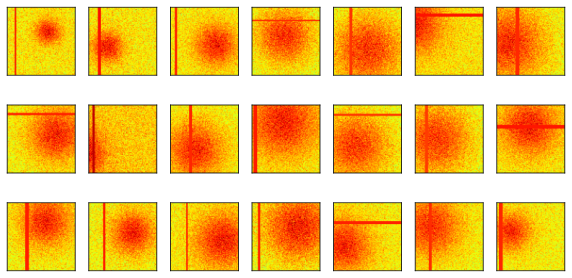

In [4]:
# visualize some images
fig,axs = plt.subplots(3,7,figsize=(10,5))

for i,ax in enumerate(axs.flatten()):
  whichpic = np.random.randint(nGauss)
  G = np.squeeze( images[whichpic,:,:].numpy() )
  ax.imshow(G,vmin=-1,vmax=1,cmap='jet')
  ax.set_xticks([])
  ax.set_yticks([])

plt.show()

# Create the DL model

In [13]:
# create a class for the model
def makeTheNet():

  class gausnet(nn.Module):
    def __init__(self):
      super().__init__()

      # encoding layer
      self.enc = nn.Sequential(
          nn.Conv2d(1,6,3,padding=1),
          nn.ReLU(),
          nn.AvgPool2d(2,2),  # nn.MaxPool2d(2,2),
          nn.Conv2d(6,4,3,padding=1),
          nn.ReLU(),
          nn.AvgPool2d(2,2)  # nn.MaxPool2d(2,2),
          )

      # decoding layer
      self.dec = nn.Sequential(
          nn.ConvTranspose2d(4,6,3,2),
          nn.ReLU(),
          nn.ConvTranspose2d(6,1,3,2),
          nn.Sigmoid()
          )

    def forward(self,x):
      return self.dec( self.enc(x) )

  # create the model instance
  net = gausnet()

  # loss function
  # lossfun = nn.MSELoss()
  lossfun = nn.BCELoss()

  # optimizer
  optimizer = torch.optim.Adam(net.parameters(),lr=.001)

  return net,lossfun,optimizer

 
torch.Size([10, 1, 91, 91])


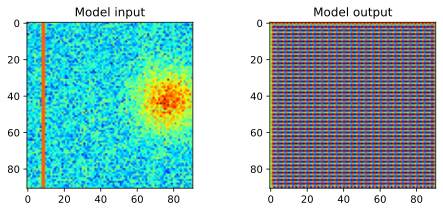

In [14]:
# test the model with one batch
net,lossfun,optimizer = makeTheNet()

yHat = net(images[:10,:,:,:])

# check size of output
print(' ')
print(yHat.shape)

# let's see how they look
fig,ax = plt.subplots(1,2,figsize=(8,3))
ax[0].imshow(torch.squeeze(images[0,0,:,:]).detach(),cmap='jet')
ax[0].set_title('Model input')
ax[1].imshow(torch.squeeze(yHat[0,0,:,:]).detach(),cmap='jet')
ax[1].set_title('Model output')

plt.show()

In [15]:
# count the total number of parameters in the model
summary(net,(1,imgSize,imgSize), device='cpu')

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 6, 91, 91]              60
              ReLU-2            [-1, 6, 91, 91]               0
         AvgPool2d-3            [-1, 6, 45, 45]               0
            Conv2d-4            [-1, 4, 45, 45]             220
              ReLU-5            [-1, 4, 45, 45]               0
         AvgPool2d-6            [-1, 4, 22, 22]               0
   ConvTranspose2d-7            [-1, 6, 45, 45]             222
              ReLU-8            [-1, 6, 45, 45]               0
   ConvTranspose2d-9            [-1, 1, 91, 91]              55
          Sigmoid-10            [-1, 1, 91, 91]               0
Total params: 557
Trainable params: 557
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.03
Forward/backward pass size (MB): 1.30
Params size (MB): 0.00
Estimated Total Siz

# Create a function that trains the model

In [16]:
# a function that trains the model
def function2trainTheModel(images, test_images, device, nGauss, numepochs:int=500):
  # create a new model
  net,lossfun,optimizer = makeTheNet()
  net.to(device)
  
  X_test = test_images.to(device)

  # initialize losses
  losses = torch.zeros(numepochs)
  test_loss = torch.zeros(numepochs)
  
  # loop over epochs
  for epochi in range(numepochs):
    net.train()

    # pick a set of images at random
    pics2use = np.random.choice(nGauss,size=32,replace=False)
    X = images[pics2use,:,:,:].to(device)

    # forward pass and loss
    yHat = net(X)
    loss = lossfun(yHat, X)
    losses[epochi] = loss.cpu().item()

    # backprop
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    # Evaluarte on test data
    net.eval()
    with torch.no_grad():
      yHat = net( X_test )
      test_loss[epochi] = lossfun(yHat, X_test).cpu().item()

  # end epochs

  # function output
  return losses, test_loss, net

# Run the model and show the results!

In [17]:
# test the model on a bit of data
numepochs = 500
losses, test_loss, net = function2trainTheModel(images, test_images, device, nGauss,numepochs=numepochs)

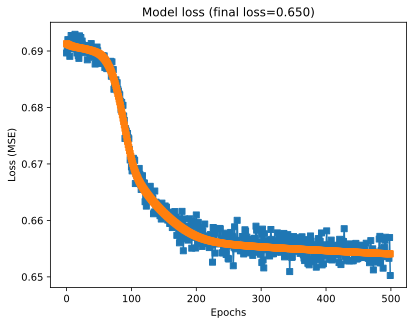

In [18]:
plt.figure()
plt.plot(losses,'s-',label='Train')
plt.plot(test_loss,'s-',label='Test')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.title('Model loss (final loss=%.3f)'%losses[-1])

plt.show()

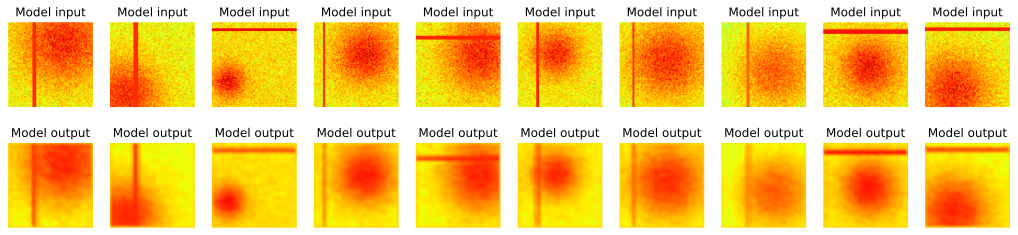

In [19]:
# visualize some images

pics2use = np.random.choice(nGauss,size=32,replace=False)
X = images[pics2use,:,:,:].to(device)
yHat = net(X)

fig,axs = plt.subplots(2,10,figsize=(18,4))

for i in range(10):

  G = torch.squeeze( X[i,0,:,:] ).cpu().detach()
  O = torch.squeeze( yHat[i,0,:,:] ).cpu().detach()

  axs[0,i].imshow(G,vmin=-1,vmax=1,cmap='jet')
  axs[0,i].axis('off')
  axs[0,i].set_title('Model input')

  axs[1,i].imshow(O,vmin=-1,vmax=1,cmap='jet')
  axs[1,i].axis('off')
  axs[1,i].set_title('Model output')

plt.show()

# Additional explorations

In [ ]:
# 1) There are no test data here, so how do you know whether the model overfit the training set? Fortunately, you can
#    simply create as much new data as you want! That's one of the advantages of generating data ;)
#    Generate a new dataset to use as a test set. How does the MSE loss compare on the test set? Did we overfit here?
# Answer: MSE Loss on the test data is basically same. Since test loss decreasing all the time and basically follows train loss, we can say that the model did not overfit.
#
# 2) The code here uses MaxPool. Are the results noticeably different if you use AvgPool instead?
# Answer: There is no difference.
#
# 3) The final output doesn't have a nonlinearity (e.g., relu, sigmoid, tanh). Does it need one? Would that help? What
#    are some arguments for and against having a nonlinear activation function on the output of the decoder? Try adding
#    one and see if it improves (via the final loss and visual inspection) the result.
# Answer: No it is not needed. It would not help to improve the results. Adding one does not change final loss and images visually a lot.
# Arguments for having non-linear output layer:
# - Additional non-linearity may help in some cases to better approximate complex functions.
# Arguments for NOT having non-linear output layer:
# - Additional non-linearity is not needed since the model is already capable of learning complex mappings without it.
#
# 4) I mentioned in the lecture "What are autoencoders and what do they do?" (section "Autoencoders") that BCEloss can be
#    used when the data are between 0 and 1. Normalize the images so they are appropriately scaled, and then use BCEloss
#    instead of MSEloss (does anything else in the model architecture need to change?). Which loss function gives a
#    better result?
# Answer: With normalized pixel values in the image and MSE loss the final loss drops from 0.045 to 0.011 conistently over multiple runs.
#   Adding BCE loss brings the final loss to about 0.65, which is much higher. For BCE loss signmoid non-linearity is needed at the output layer.
#